# Exploratory Data Analysis — Customer Segmentation

**Goal:** Understand the Online Retail II dataset before building the segmentation model.

### Sections
1. Setup & Data Loading
2. Dataset Overview
3. Data Quality Assessment
4. Sales Trends Over Time
5. Product Analysis
6. Customer Analysis
7. Geographic Analysis
8. Revenue Distribution
9. Key Insights & Next Steps

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os, sys

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)

BLUE   = '#2563eb'
GREEN  = '#059669'
ORANGE = '#d97706'
RED    = '#dc2626'
PURPLE = '#7c3aed'
COLORS = [BLUE, GREEN, ORANGE, RED, PURPLE,
          '#0891b2', '#be185d', '#854d0e']


In [3]:
# Load CSV file
DATA_PATH = '../data/raw/online_retail_II.csv'

print('Loading data...')
df = pd.read_csv(DATA_PATH, encoding='unicode_escape')
print(f'Shape: {df.shape}')
df.head()

Loading data...
Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


---
## 2. Dataset Overview

In [4]:
print('=== Basic Info ===')
print(f'Rows:              {df.shape[0]:,}')
print(f'Columns:           {df.shape[1]}')
print(f'Memory:            {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'Date range:        {df["InvoiceDate"].min()} to {df["InvoiceDate"].max()}')
print(f'Unique invoices:   {df["Invoice"].nunique():,}')
print(f'Unique products:   {df["StockCode"].nunique():,}')
print(f'Unique customers:  {df["Customer ID"].nunique():,}')
print(f'Unique countries:  {df["Country"].nunique():,}')
print()
print('=== Data Types ===')
print(df.dtypes)

=== Basic Info ===
Rows:              1,067,371
Columns:           8
Memory:            404.5 MB
Date range:        2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique invoices:   53,628
Unique products:   5,305
Unique customers:  5,942
Unique countries:  43

=== Data Types ===
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


In [ ]:
print('=== Summary Statistics ===')
df[['Quantity', 'Price']].describe().T.style.background_gradient(cmap='Blues', axis=1)

---
## 3. Data Quality Assessment

In [6]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]
print(missing_df)

print(f'\n=== Cancelled Transactions ===')
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
print(f'Cancelled rows: {len(cancelled):,} ({len(cancelled)/len(df)*100:.2f}%)')

print(f'\n=== Negative Quantities ===')
neg_qty = df[df['Quantity'] < 0]
print(f'Negative quantity rows: {len(neg_qty):,} ({len(neg_qty)/len(df)*100:.2f}%)')

print(f'\n=== Negative/Zero Prices ===')
neg_price = df[df['Price'] <= 0]
print(f'Zero/negative price rows: {len(neg_price):,} ({len(neg_price)/len(df)*100:.2f}%)')

print(f'\n=== Duplicates ===')
print(f'Duplicate rows: {df.duplicated().sum():,}')

=== Missing Values ===
              Count  Percentage
Description    4382        0.41
Customer ID  243007       22.77

=== Cancelled Transactions ===
Cancelled rows: 19,494 (1.83%)

=== Negative Quantities ===
Negative quantity rows: 22,950 (2.15%)

=== Negative/Zero Prices ===
Zero/negative price rows: 6,207 (0.58%)

=== Duplicates ===
Duplicate rows: 34,335


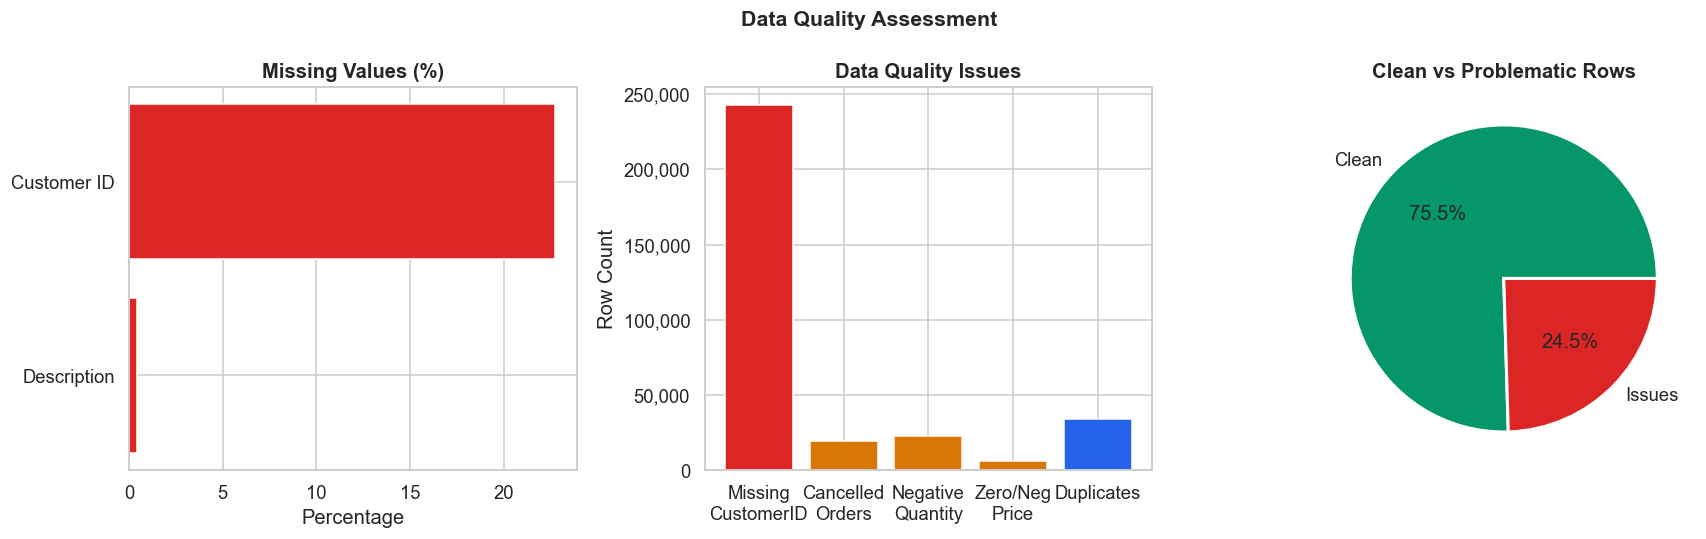

Clean rows available for analysis: 805,549 (75.5%)


In [7]:
# Visualise data quality
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Missing values
missing_plot = missing_df[missing_df['Count'] > 0]
axes[0].barh(missing_plot.index, missing_plot['Percentage'], color=RED)
axes[0].set_title('Missing Values (%)', fontweight='bold')
axes[0].set_xlabel('Percentage')

# Issue breakdown
issues = {
    'Missing\nCustomerID': df['Customer ID'].isnull().sum(),
    'Cancelled\nOrders':   len(cancelled),
    'Negative\nQuantity':  len(neg_qty),
    'Zero/Neg\nPrice':     len(neg_price),
    'Duplicates':          df.duplicated().sum(),
}
axes[1].bar(issues.keys(), issues.values(),
            color=[RED, ORANGE, ORANGE, ORANGE, BLUE])
axes[1].set_title('Data Quality Issues', fontweight='bold')
axes[1].set_ylabel('Row Count')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Clean vs dirty
clean_mask = (
    df['Customer ID'].notna() &
    ~df['Invoice'].astype(str).str.startswith('C') &
    (df['Quantity'] > 0) &
    (df['Price'] > 0)
)
axes[2].pie(
    [clean_mask.sum(), (~clean_mask).sum()],
    labels=['Clean', 'Issues'],
    colors=[GREEN, RED], autopct='%1.1f%%',
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[2].set_title('Clean vs Problematic Rows', fontweight='bold')

plt.suptitle('Data Quality Assessment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Clean rows available for analysis: {clean_mask.sum():,} ({clean_mask.mean()*100:.1f}%)')

---
## 4. Sales Trends Over Time

In [8]:
# Work with clean data from here
df_clean = df[
    df['Customer ID'].notna() &
    ~df['Invoice'].astype(str).str.startswith('C') &
    (df['Quantity'] > 0) &
    (df['Price'] > 0)
].copy()

df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Revenue']     = df_clean['Quantity'] * df_clean['Price']
df_clean['YearMonth']   = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['Month']       = df_clean['InvoiceDate'].dt.month
df_clean['DayOfWeek']   = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour']        = df_clean['InvoiceDate'].dt.hour

print(f'Clean dataset: {df_clean.shape}')
print(f'Unique customers: {df_clean["Customer ID"].nunique():,}')
print(f'Total revenue: £{df_clean["Revenue"].sum():,.2f}')

Clean dataset: (805549, 13)
Unique customers: 5,878
Total revenue: £17,743,429.18


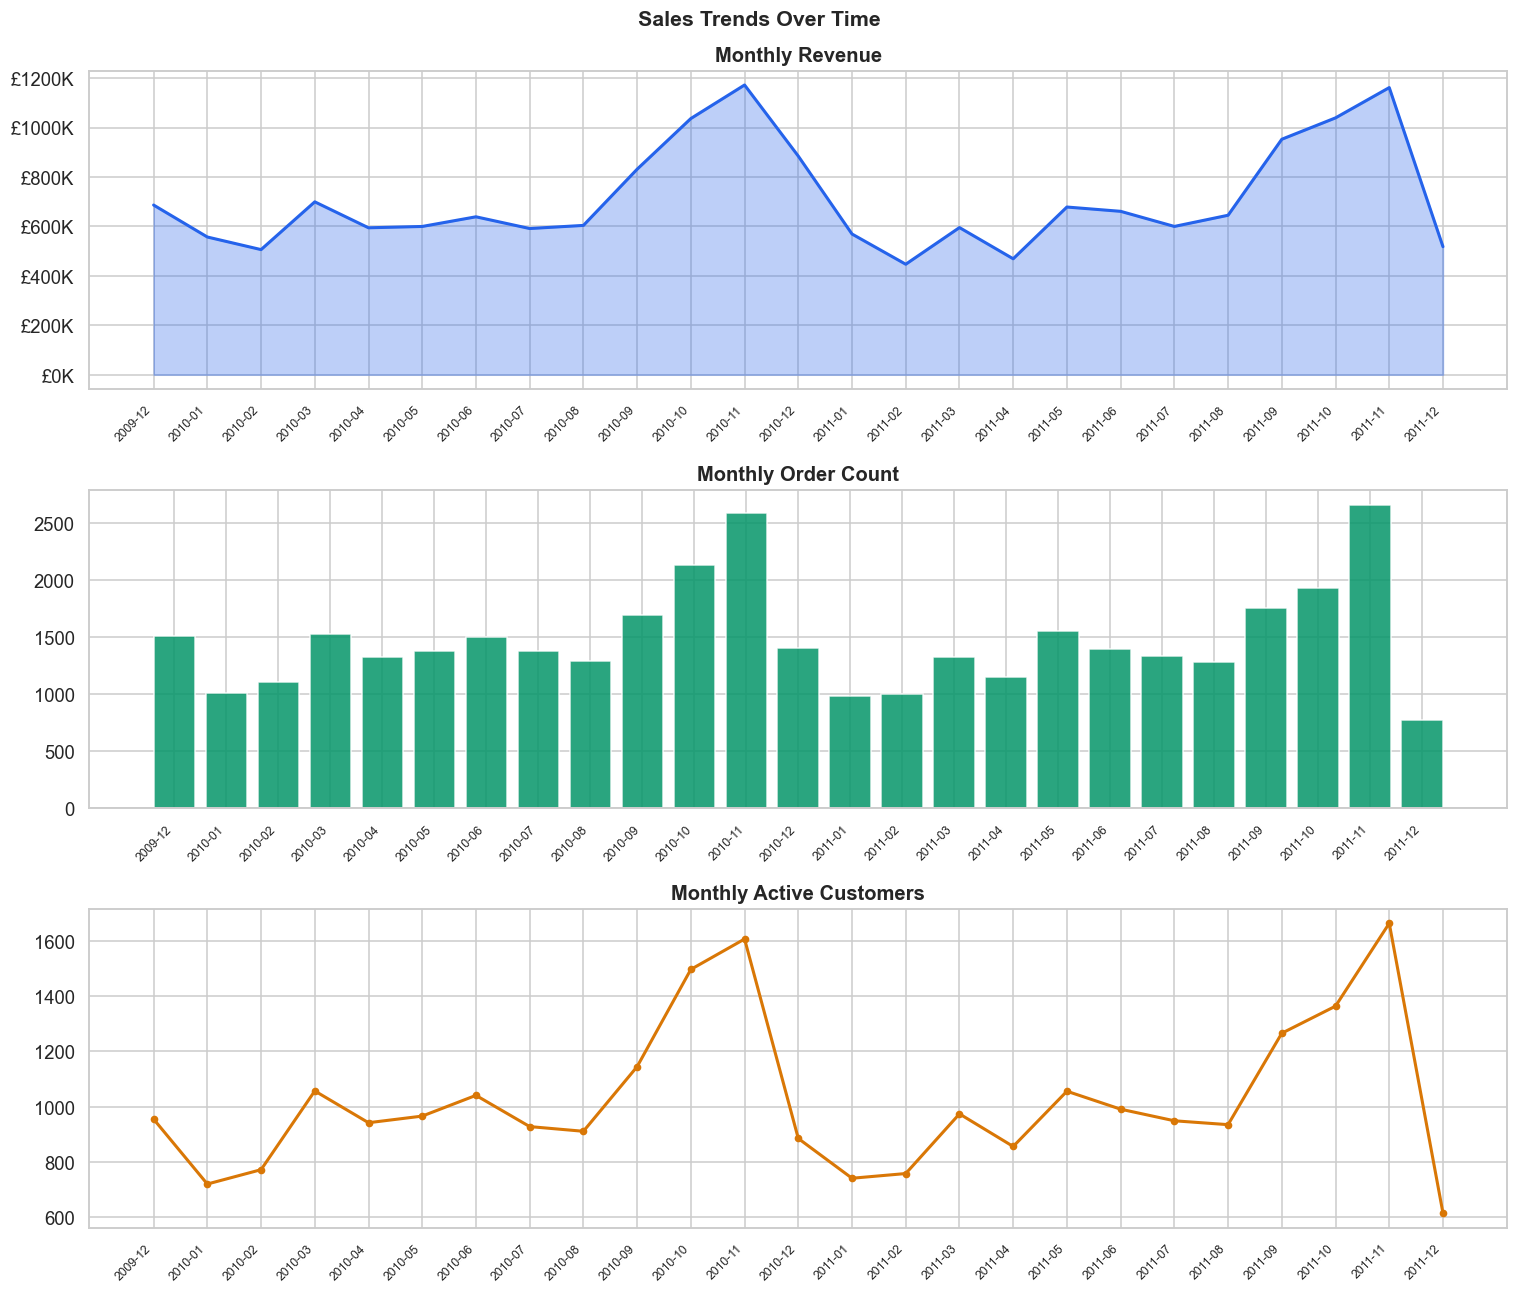

In [9]:
# Monthly revenue trend
monthly = df_clean.groupby('YearMonth').agg(
    Revenue     = ('Revenue',     'sum'),
    Orders      = ('Invoice',     'nunique'),
    Customers   = ('Customer ID', 'nunique')
).reset_index()
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].fill_between(range(len(monthly)), monthly['Revenue'],
                     alpha=0.3, color=BLUE)
axes[0].plot(range(len(monthly)), monthly['Revenue'],
             color=BLUE, linewidth=2)
axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels(monthly['YearMonth_str'], rotation=45, ha='right', fontsize=8)
axes[0].set_title('Monthly Revenue', fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

axes[1].bar(range(len(monthly)), monthly['Orders'], color=GREEN, alpha=0.85)
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['YearMonth_str'], rotation=45, ha='right', fontsize=8)
axes[1].set_title('Monthly Order Count', fontweight='bold')

axes[2].plot(range(len(monthly)), monthly['Customers'],
             color=ORANGE, linewidth=2, marker='o', markersize=4)
axes[2].set_xticks(range(len(monthly)))
axes[2].set_xticklabels(monthly['YearMonth_str'], rotation=45, ha='right', fontsize=8)
axes[2].set_title('Monthly Active Customers', fontweight='bold')

plt.suptitle('Sales Trends Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

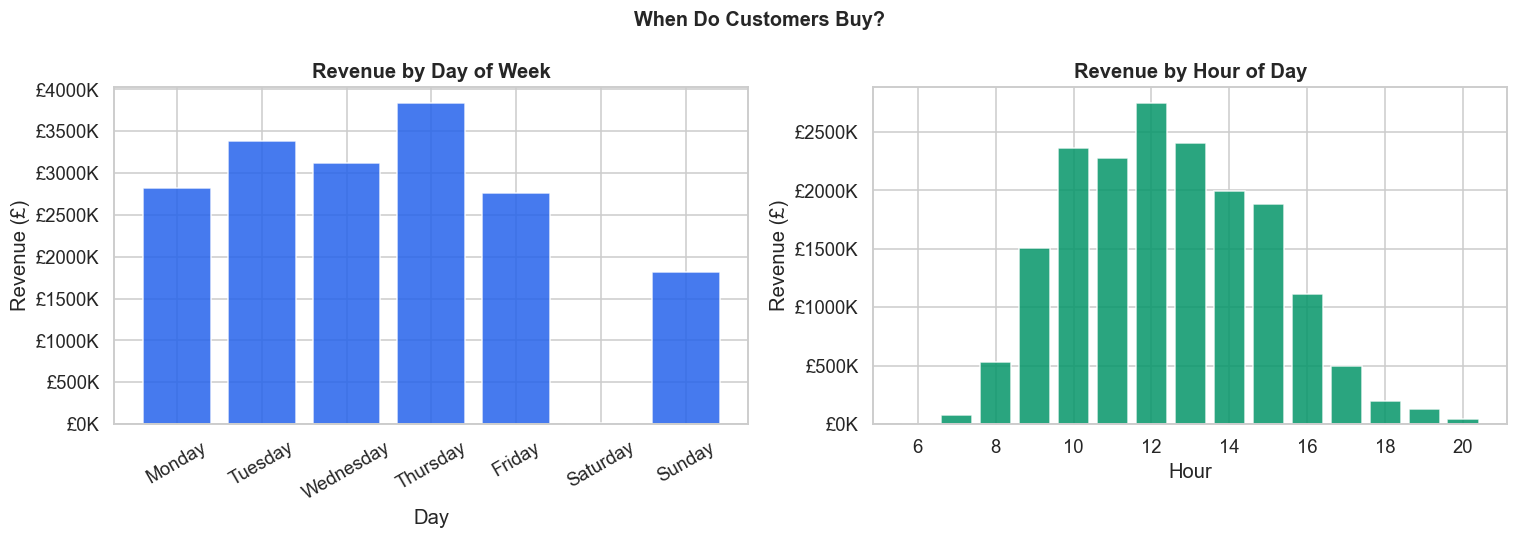

In [10]:
# Day of week and hour analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_rev = df_clean.groupby('DayOfWeek')['Revenue'].sum().reindex(day_order)
axes[0].bar(day_rev.index, day_rev.values, color=BLUE, alpha=0.85)
axes[0].set_title('Revenue by Day of Week', fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0].tick_params(axis='x', rotation=30)

hour_rev = df_clean.groupby('Hour')['Revenue'].sum()
axes[1].bar(hour_rev.index, hour_rev.values, color=GREEN, alpha=0.85)
axes[1].set_title('Revenue by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Revenue (£)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.suptitle('When Do Customers Buy?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Product Analysis

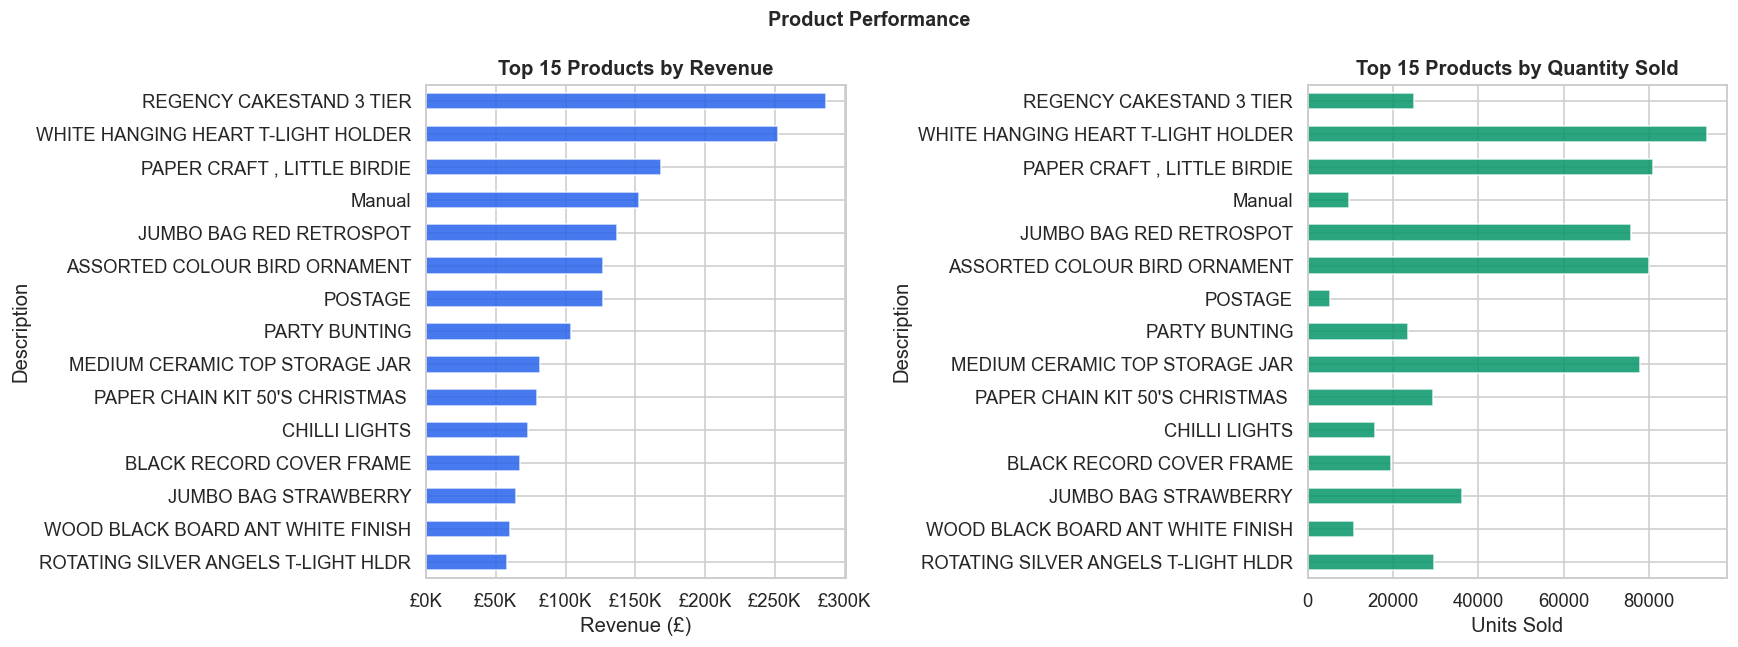

In [11]:
# Top products by revenue
top_products = df_clean.groupby('Description').agg(
    Revenue  = ('Revenue',  'sum'),
    Quantity = ('Quantity', 'sum'),
    Orders   = ('Invoice',  'nunique')
).sort_values('Revenue', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_products['Revenue'].plot(kind='barh', ax=axes[0], color=BLUE, alpha=0.85)
axes[0].set_title('Top 15 Products by Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue (£)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0].invert_yaxis()

top_products['Quantity'].plot(kind='barh', ax=axes[1], color=GREEN, alpha=0.85)
axes[1].set_title('Top 15 Products by Quantity Sold', fontweight='bold')
axes[1].set_xlabel('Units Sold')
axes[1].invert_yaxis()

plt.suptitle('Product Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

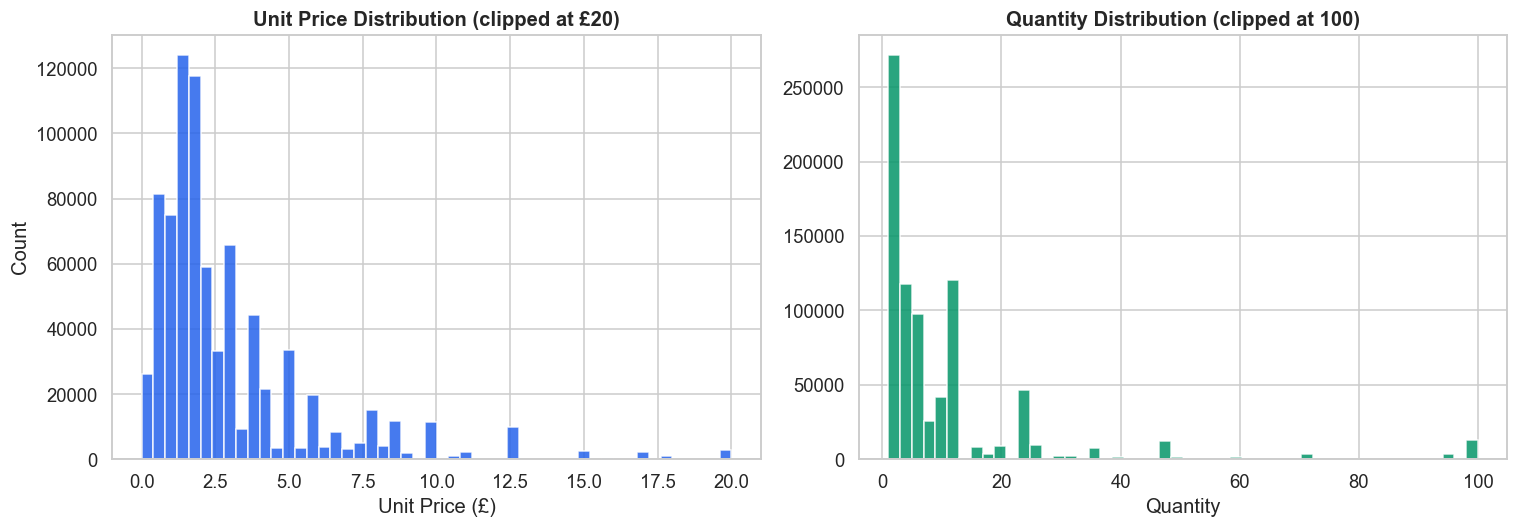

Median unit price: £1.95
Median quantity:   5 units


In [12]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean['Price'].clip(0, 20).hist(bins=50, ax=axes[0], color=BLUE, alpha=0.85)
axes[0].set_title('Unit Price Distribution (clipped at £20)', fontweight='bold')
axes[0].set_xlabel('Unit Price (£)')
axes[0].set_ylabel('Count')

df_clean['Quantity'].clip(0, 100).hist(bins=50, ax=axes[1], color=GREEN, alpha=0.85)
axes[1].set_title('Quantity Distribution (clipped at 100)', fontweight='bold')
axes[1].set_xlabel('Quantity')

plt.tight_layout()
plt.show()

print(f'Median unit price: £{df_clean["Price"].median():.2f}')
print(f'Median quantity:   {df_clean["Quantity"].median():.0f} units')

---
## 6. Customer Analysis

In [13]:
# Customer-level aggregation
customer_stats = df_clean.groupby('Customer ID').agg(
    TotalRevenue  = ('Revenue',     'sum'),
    TotalOrders   = ('Invoice',     'nunique'),
    TotalItems    = ('Quantity',    'sum'),
    AvgOrderValue = ('Revenue',     'mean'),
    FirstPurchase = ('InvoiceDate', 'min'),
    LastPurchase  = ('InvoiceDate', 'max'),
).reset_index()

customer_stats['DaysSinceFirst'] = (
    customer_stats['LastPurchase'] - customer_stats['FirstPurchase']
).dt.days

print('=== Customer Statistics ===')
print(f'Total customers:           {len(customer_stats):,}')
print(f'Avg revenue per customer:  £{customer_stats["TotalRevenue"].mean():,.2f}')
print(f'Median revenue:            £{customer_stats["TotalRevenue"].median():,.2f}')
print(f'Avg orders per customer:   {customer_stats["TotalOrders"].mean():.1f}')
print(f'One-time buyers:           {(customer_stats["TotalOrders"]==1).sum():,} ({(customer_stats["TotalOrders"]==1).mean()*100:.1f}%)')

=== Customer Statistics ===
Total customers:           5,878
Avg revenue per customer:  £3,018.62
Median revenue:            £898.91
Avg orders per customer:   6.3
One-time buyers:           1,623 (27.6%)


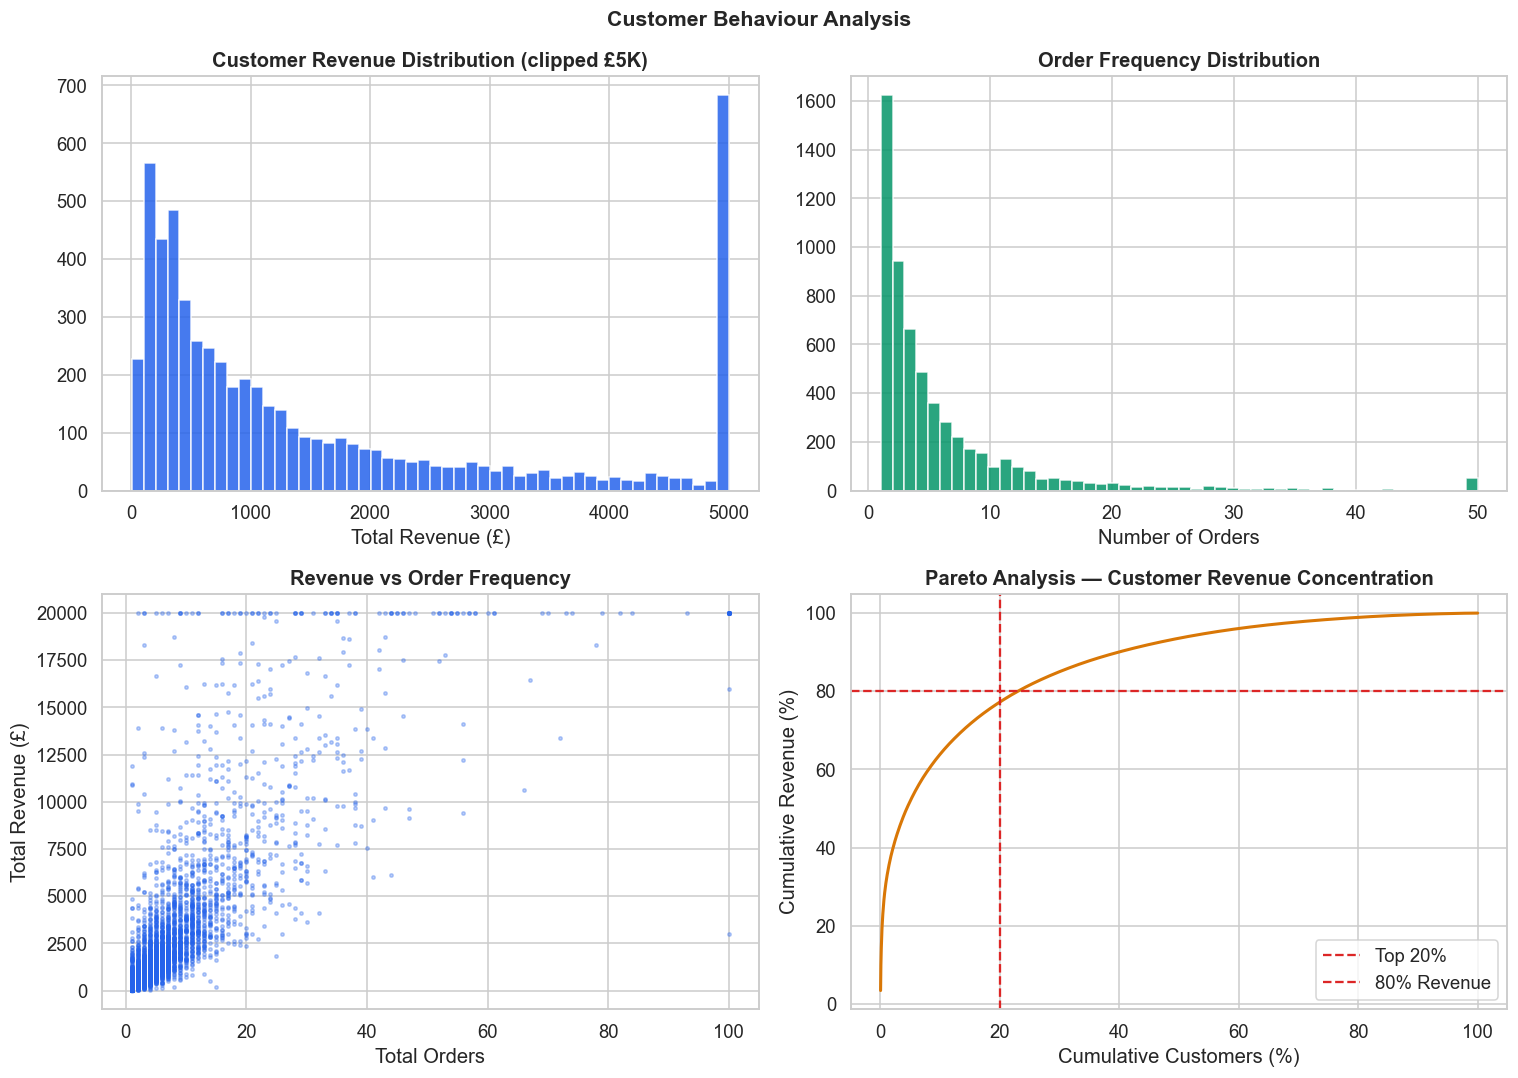

Top 20% of customers generate 77.2% of revenue


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Revenue distribution
customer_stats['TotalRevenue'].clip(0, 5000).hist(
    bins=50, ax=axes[0,0], color=BLUE, alpha=0.85)
axes[0,0].set_title('Customer Revenue Distribution (clipped £5K)', fontweight='bold')
axes[0,0].set_xlabel('Total Revenue (£)')

# Order frequency
customer_stats['TotalOrders'].clip(0, 50).hist(
    bins=50, ax=axes[0,1], color=GREEN, alpha=0.85)
axes[0,1].set_title('Order Frequency Distribution', fontweight='bold')
axes[0,1].set_xlabel('Number of Orders')

# Revenue vs Orders scatter
axes[1,0].scatter(
    customer_stats['TotalOrders'].clip(0, 100),
    customer_stats['TotalRevenue'].clip(0, 20000),
    alpha=0.3, s=5, color=BLUE
)
axes[1,0].set_title('Revenue vs Order Frequency', fontweight='bold')
axes[1,0].set_xlabel('Total Orders')
axes[1,0].set_ylabel('Total Revenue (£)')

# Top 20% customers revenue share (Pareto)
customer_sorted = customer_stats.sort_values('TotalRevenue', ascending=False)
customer_sorted['CumRevenuePct'] = customer_sorted['TotalRevenue'].cumsum() / \
                                    customer_sorted['TotalRevenue'].sum() * 100
customer_sorted['CustomerPct'] = range(1, len(customer_sorted)+1)
customer_sorted['CustomerPct'] = customer_sorted['CustomerPct'] / \
                                  len(customer_sorted) * 100
axes[1,1].plot(customer_sorted['CustomerPct'],
               customer_sorted['CumRevenuePct'], color=ORANGE, linewidth=2)
axes[1,1].axvline(x=20, color=RED, linestyle='--', linewidth=1.5, label='Top 20%')
axes[1,1].axhline(y=80, color=RED, linestyle='--', linewidth=1.5, label='80% Revenue')
axes[1,1].set_title('Pareto Analysis — Customer Revenue Concentration', fontweight='bold')
axes[1,1].set_xlabel('Cumulative Customers (%)')
axes[1,1].set_ylabel('Cumulative Revenue (%)')
axes[1,1].legend()

plt.suptitle('Customer Behaviour Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find top 20% revenue share
top20_rev = customer_sorted.iloc[:int(len(customer_sorted)*0.2)]['TotalRevenue'].sum()
total_rev  = customer_sorted['TotalRevenue'].sum()
print(f'Top 20% of customers generate {top20_rev/total_rev*100:.1f}% of revenue')

---
## 7. Geographic Analysis

=== Top 10 Countries by Revenue ===
                     Revenue  Customers  Orders
Country                                        
United Kingdom  1.472315e+07       5350   33541
EIRE            6.216311e+05          5     567
Netherlands     5.542323e+05         22     228
Germany         4.312625e+05        107     789
France          3.552575e+05         95     614
Australia       1.699681e+05         15      95
Spain           1.091785e+05         41     154
Switzerland     1.003653e+05         22      90
Sweden          9.154972e+04         19     104
Denmark         6.986219e+04         12      43


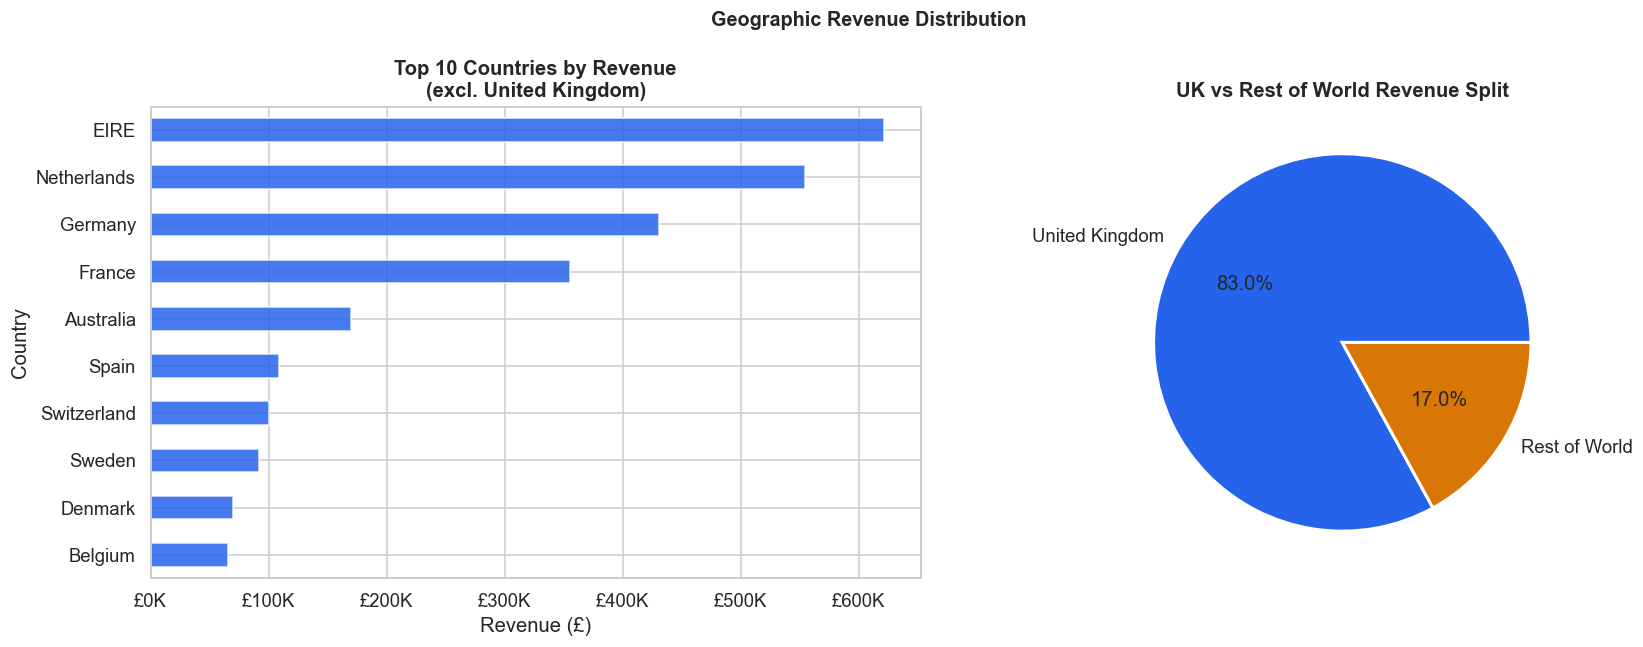

In [15]:
# Revenue by country
country_rev = df_clean.groupby('Country').agg(
    Revenue   = ('Revenue',     'sum'),
    Customers = ('Customer ID', 'nunique'),
    Orders    = ('Invoice',     'nunique')
).sort_values('Revenue', ascending=False)

print('=== Top 10 Countries by Revenue ===')
print(country_rev.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 countries by revenue (excluding UK which dominates)
top_countries = country_rev[country_rev.index != 'United Kingdom'].head(10)
top_countries['Revenue'].plot(kind='barh', ax=axes[0],
                               color=BLUE, alpha=0.85)
axes[0].set_title('Top 10 Countries by Revenue\n(excl. United Kingdom)',
                   fontweight='bold')
axes[0].set_xlabel('Revenue (£)')
axes[0].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0].invert_yaxis()

# UK vs Rest of World
uk_rev    = country_rev.loc['United Kingdom', 'Revenue']
other_rev = country_rev[country_rev.index != 'United Kingdom']['Revenue'].sum()
axes[1].pie(
    [uk_rev, other_rev],
    labels=['United Kingdom', 'Rest of World'],
    colors=[BLUE, ORANGE], autopct='%1.1f%%',
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('UK vs Rest of World Revenue Split', fontweight='bold')

plt.suptitle('Geographic Revenue Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Revenue Distribution

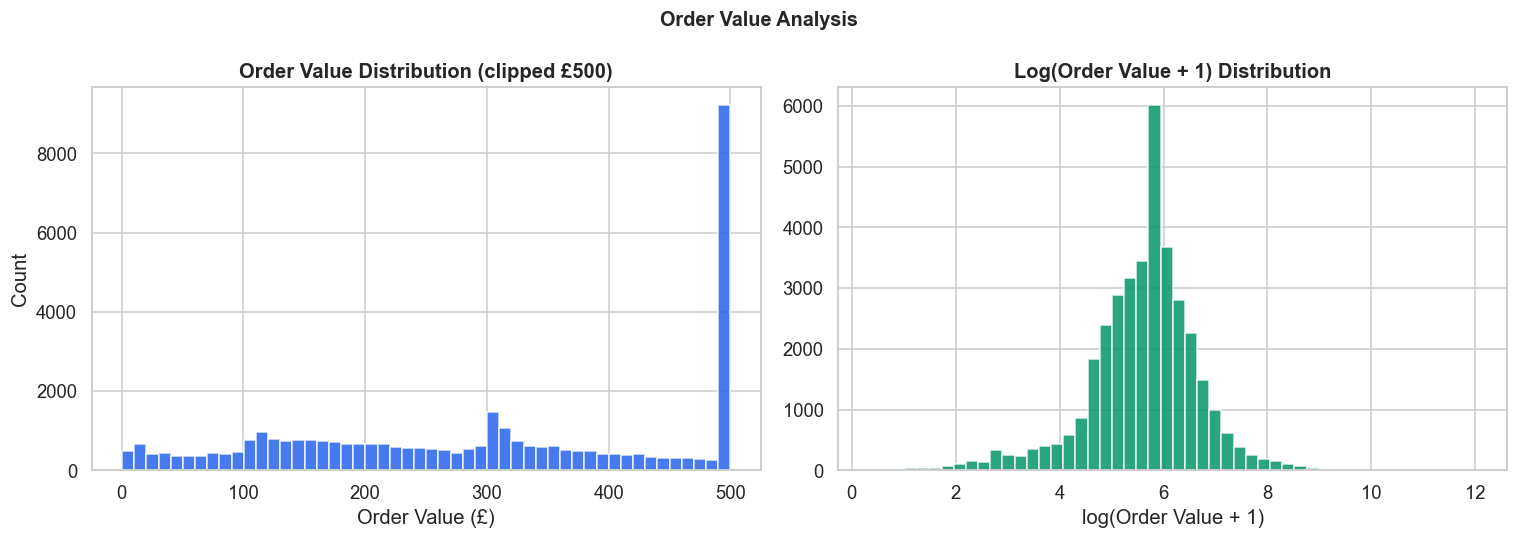

Mean order value:   £479.95
Median order value: £305.25
Max order value:    £168,469.60
Orders under £50:   6.4%


In [16]:
# Order value distribution
order_value = df_clean.groupby('Invoice')['Revenue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_value.clip(0, 500).hist(bins=50, ax=axes[0], color=BLUE, alpha=0.85)
axes[0].set_title('Order Value Distribution (clipped £500)', fontweight='bold')
axes[0].set_xlabel('Order Value (£)')
axes[0].set_ylabel('Count')

np.log1p(order_value).hist(bins=50, ax=axes[1], color=GREEN, alpha=0.85)
axes[1].set_title('Log(Order Value + 1) Distribution', fontweight='bold')
axes[1].set_xlabel('log(Order Value + 1)')

plt.suptitle('Order Value Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean order value:   £{order_value.mean():.2f}')
print(f'Median order value: £{order_value.median():.2f}')
print(f'Max order value:    £{order_value.max():,.2f}')
print(f'Orders under £50:   {(order_value < 50).mean()*100:.1f}%')

---
## 9. Key Insights & Next Steps

In [17]:
# Summary stats for the insights box
one_time = (customer_stats['TotalOrders'] == 1).mean() * 100
uk_pct   = uk_rev / (uk_rev + other_rev) * 100
top20_pct = top20_rev / total_rev * 100

print(f"""
=================================================================
                     KEY EDA INSIGHTS
=================================================================

  1. DATASET SIZE
     {len(df_clean):,} clean transactions from {df_clean['Customer ID'].nunique():,} unique customers
     after removing missing CustomerIDs, cancellations, and bad data.

  2. PARETO PRINCIPLE CONFIRMED
     Top 20% of customers generate {top20_pct:.1f}% of total revenue.
     Segmentation will help identify and retain these high-value customers.

  3. ONE-TIME BUYERS
     {one_time:.1f}% of customers purchased only once.
     A key segment to target for reactivation campaigns.

  4. UK DOMINANCE
     United Kingdom accounts for {uk_pct:.1f}% of revenue.
     International expansion opportunity in Netherlands, Germany, France.

  5. SEASONAL PATTERNS
     Clear revenue spike in Q4 (Oct-Nov) — holiday shopping season.
     Peak buying hours: 10am-3pm on weekdays.

  6. REVENUE SKEWNESS
     Both order value and customer revenue are heavily right-skewed.
     Log transformation required before clustering.

  7. RICH TRANSACTION HISTORY
     2 years of data available for robust RFM calculation.
     Enough history to distinguish loyal from lapsed customers.

=================================================================
  NEXT STEP -> 02_feature_engineering.ipynb
  - Compute RFM features per customer
  - Apply log transformation
  - Scale features for clustering
  - Visualise RFM distributions
=================================================================
""")


                     KEY EDA INSIGHTS

  1. DATASET SIZE
     805,549 clean transactions from 5,878 unique customers
     after removing missing CustomerIDs, cancellations, and bad data.

  2. PARETO PRINCIPLE CONFIRMED
     Top 20% of customers generate 77.2% of total revenue.
     Segmentation will help identify and retain these high-value customers.

  3. ONE-TIME BUYERS
     27.6% of customers purchased only once.
     A key segment to target for reactivation campaigns.

  4. UK DOMINANCE
     United Kingdom accounts for 83.0% of revenue.
     International expansion opportunity in Netherlands, Germany, France.

  5. SEASONAL PATTERNS
     Clear revenue spike in Q4 (Oct-Nov) — holiday shopping season.
     Peak buying hours: 10am-3pm on weekdays.

  6. REVENUE SKEWNESS
     Both order value and customer revenue are heavily right-skewed.
     Log transformation required before clustering.

  7. RICH TRANSACTION HISTORY
     2 years of data available for robust RFM calculation.
    